# Advanced Regression Engine

## Objective
Build and compare multiple regression models for house price prediction.

**Models:** Linear Regression, Ridge, Lasso, Decision Tree, Random Forest, SVR

---

In [4]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np


In [5]:
df = pd.read_csv("Advanced_Regression_HousePrice_Dataset_3800 - Advanced_Regression_HousePrice_Dataset_3800.csv.csv")

In [6]:
df

,property_id,sale_date,area_sqft,bedrooms,bathrooms,location_score,property_age,distance_city_km,near_school,near_metro,crime_rate_index,house_price_inr
0,200001,2014-01-01,2181,6,4,8.1,21,3.8,0,0,4.84,35154898
1,200002,2019-12-01,2383,5,4,5.3,28,10.9,1,1,2.89,26710893
2,200003,2016-10-01,1047,3,3,5.9,7,27.5,0,1,4.04,11216242
3,200004,2013-03-01,1753,4,3,7.0,27,12.1,0,0,3.28,21984310
4,200005,2013-07-01,1728,4,4,10.0,32,1.4,0,1,3.84,25080429
...,...,...,...,...,...,...,...,...,...,...,...,...
3795,203796,2010-04-01,992,3,3,7.4,22,11.6,0,0,3.45,10901127
3796,203797,2019-04-01,2295,4,4,2.8,22,23.0,0,0,5.38,20662246
3797,203798,2020-10-01,2050,2,1,8.7,38,11.0,0,0,2.90,32486165
3798,203799,2012-03-01,1957,6,4,7.8,22,1.2,0,0,4.31,25004531


In [7]:
df.isnull().sum()

property_id         0
sale_date           0
area_sqft           0
bedrooms            0
bathrooms           0
location_score      0
property_age        0
distance_city_km    0
near_school         0
near_metro          0
crime_rate_index    0
house_price_inr     0
dtype: int64

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3800 entries, 0 to 3799
Data columns (total 12 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   property_id       3800 non-null   int64  
 1   sale_date         3800 non-null   object 
 2   area_sqft         3800 non-null   int64  
 3   bedrooms          3800 non-null   int64  
 4   bathrooms         3800 non-null   int64  
 5   location_score    3800 non-null   float64
 6   property_age      3800 non-null   int64  
 7   distance_city_km  3800 non-null   float64
 8   near_school       3800 non-null   int64  
 9   near_metro        3800 non-null   int64  
 10  crime_rate_index  3800 non-null   float64
 11  house_price_inr   3800 non-null   int64  
dtypes: float64(3), int64(8), object(1)
memory usage: 356.4+ KB


In [9]:
df.describe()

,property_id,area_sqft,bedrooms,bathrooms,location_score,property_age,distance_city_km,near_school,near_metro,crime_rate_index,house_price_inr
count,3800.00000,3800.000000,3800.000000,3800.000000,3800.000000,3800.000000,3800.000000,3800.000000,3800.000000,3800.000000,3.800000e+03
mean,201900.50000,1716.925526,3.428158,2.916316,6.502237,22.537105,13.085132,0.548421,0.472895,4.242911,2.071940e+07
std,1097.10984,582.996559,1.356682,1.133540,1.766945,12.325740,6.537425,0.497715,0.499330,2.045371,8.707465e+06
min,200001.00000,500.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,0.000000,0.500000,1.506126e+06
25%,200950.75000,1322.000000,2.000000,2.000000,5.300000,14.000000,8.500000,0.000000,0.000000,2.810000,1.446895e+07
50%,201900.50000,1700.500000,3.000000,3.000000,6.500000,20.000000,13.000000,1.000000,0.000000,4.220000,1.989180e+07
75%,202850.25000,2105.000000,4.000000,4.000000,7.700000,29.000000,17.500000,1.000000,1.000000,5.650000,2.596062e+07
max,203800.00000,3776.000000,7.000000,6.000000,10.000000,80.000000,38.700000,1.000000,1.000000,12.000000,5.930315e+07


In [10]:
df["sale_date"]

0       2014-01-01
1       2019-12-01
2       2016-10-01
3       2013-03-01
4       2013-07-01
           ...    
3795    2010-04-01
3796    2019-04-01
3797    2020-10-01
3798    2012-03-01
3799    2013-01-01
Name: sale_date, Length: 3800, dtype: object

In [11]:
X = df["house_price_inr"].drop

In [12]:
X

<bound method Series.drop of 0       35154898
1       26710893
2       11216242
3       21984310
4       25080429
          ...   
3795    10901127
3796    20662246
3797    32486165
3798    25004531
3799    24138565
Name: house_price_inr, Length: 3800, dtype: int64>

In [13]:
cols = df.columns
cols

Index(['property_id', 'sale_date', 'area_sqft', 'bedrooms', 'bathrooms',
       'location_score', 'property_age', 'distance_city_km', 'near_school',
       'near_metro', 'crime_rate_index', 'house_price_inr'],
      dtype='object')

## Part B: Data Understanding & Preparation

- Dataset inspection
- Missing values analysis
- Descriptive statistics
- Outlier detection
- Feature engineering from date column

In [14]:
num_col = df.select_dtypes(include=["int64","float64"]).columns
num_col

Index(['property_id', 'area_sqft', 'bedrooms', 'bathrooms', 'location_score',
       'property_age', 'distance_city_km', 'near_school', 'near_metro',
       'crime_rate_index', 'house_price_inr'],
      dtype='object')

In [15]:
df.shape

(3800, 12)

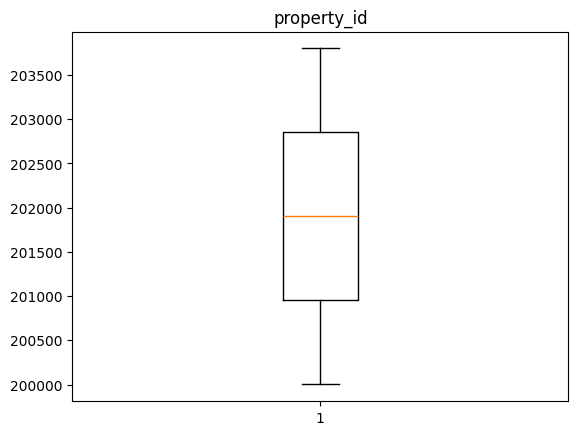

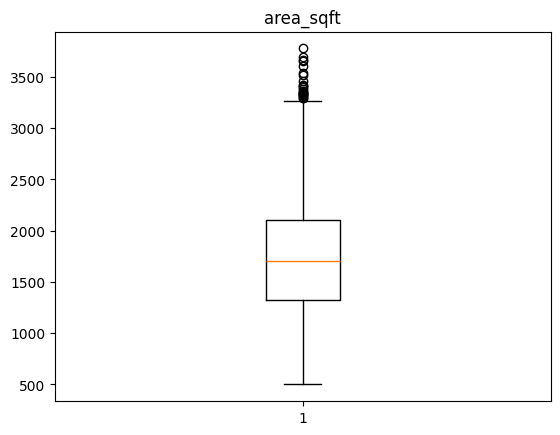

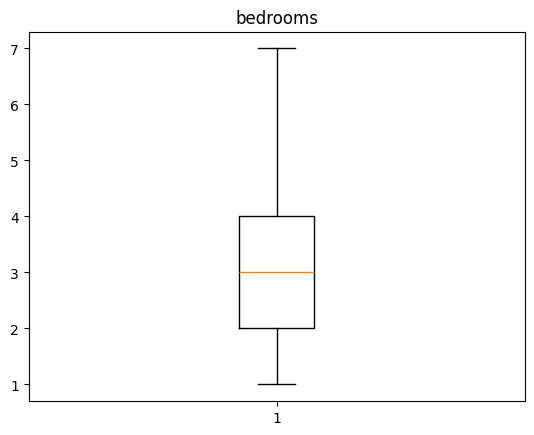

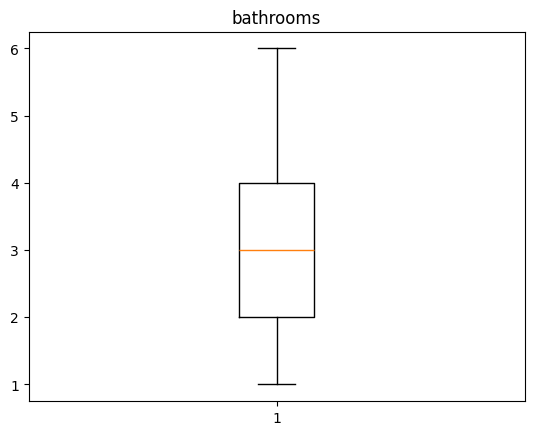

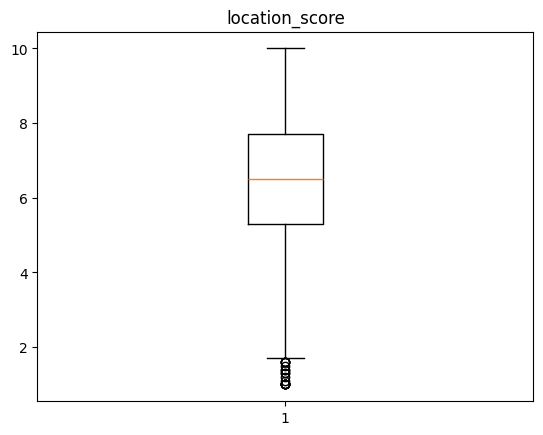

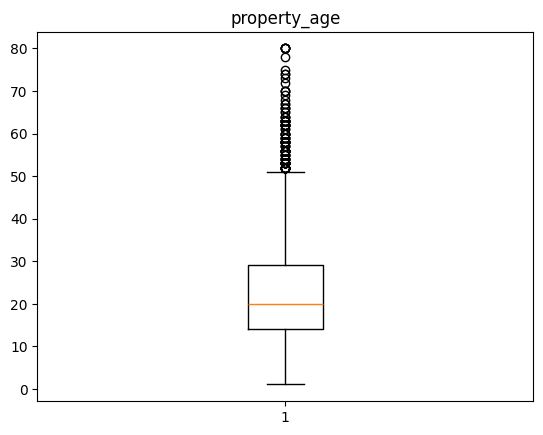

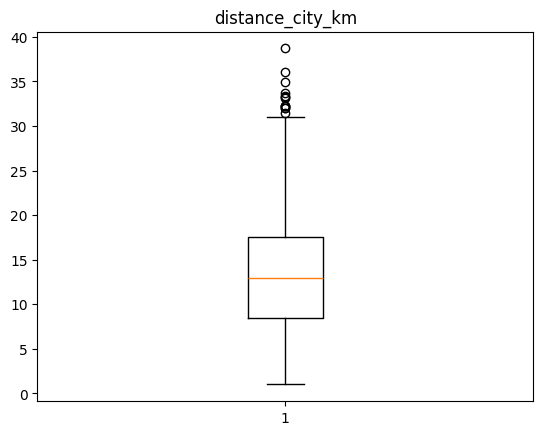

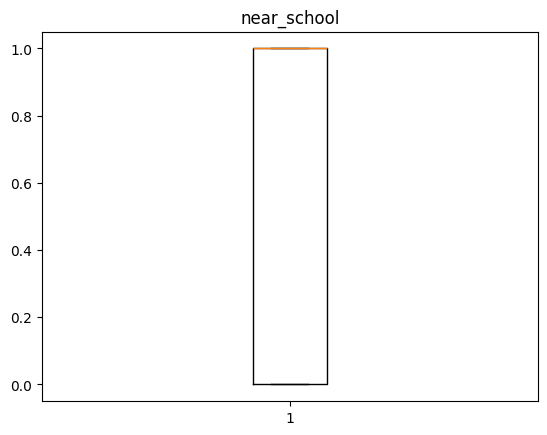

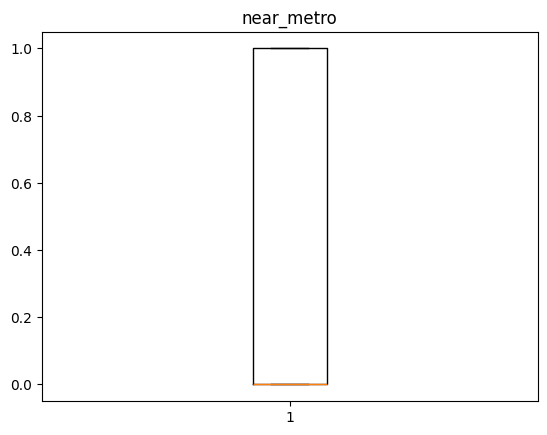

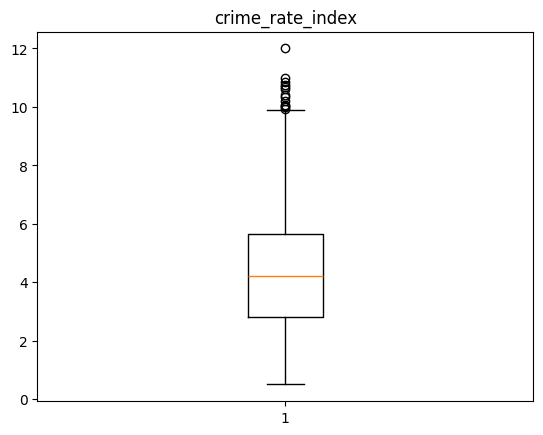

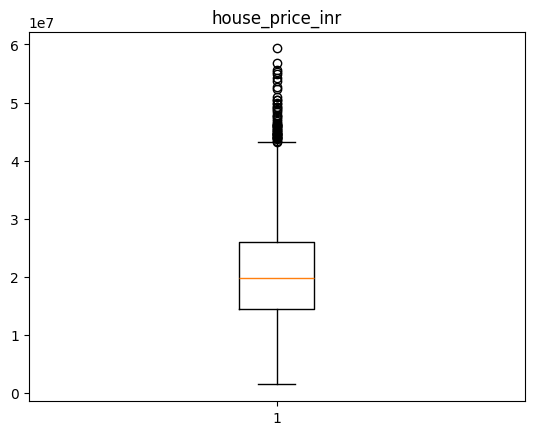

In [16]:
for col in num_col :
    plt.boxplot(x=df[col])
    plt.title(col)
    plt.show()

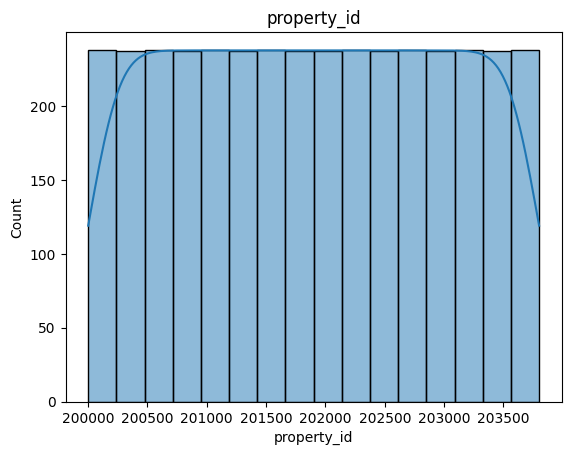

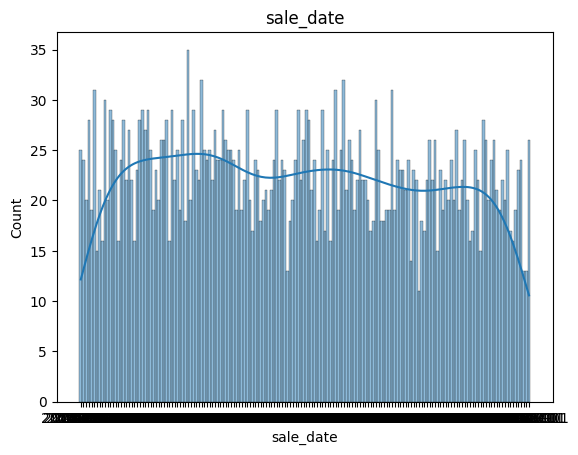

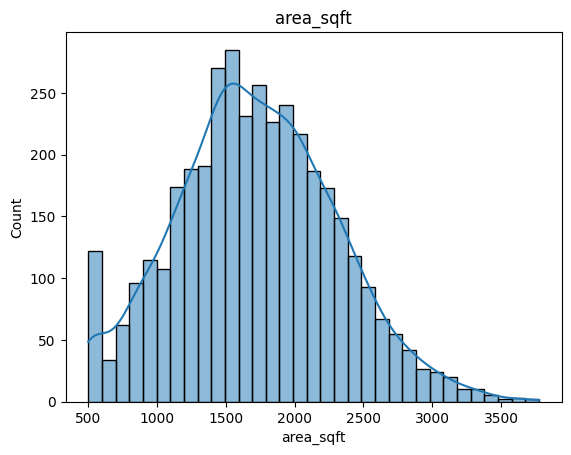

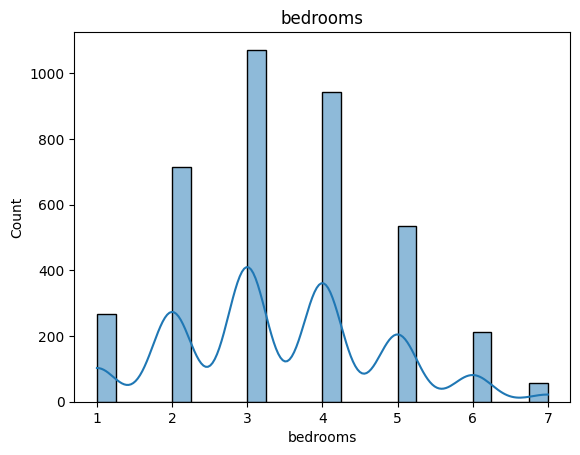

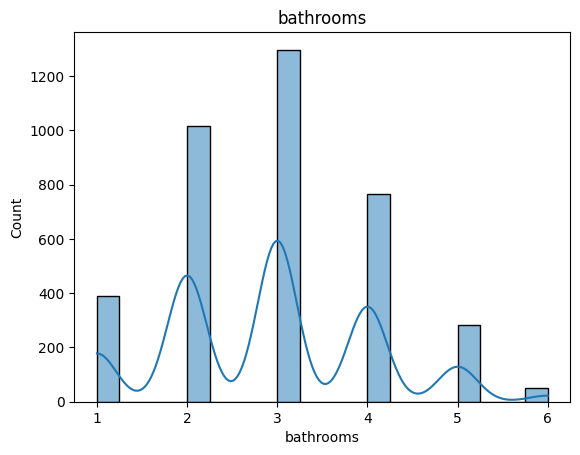

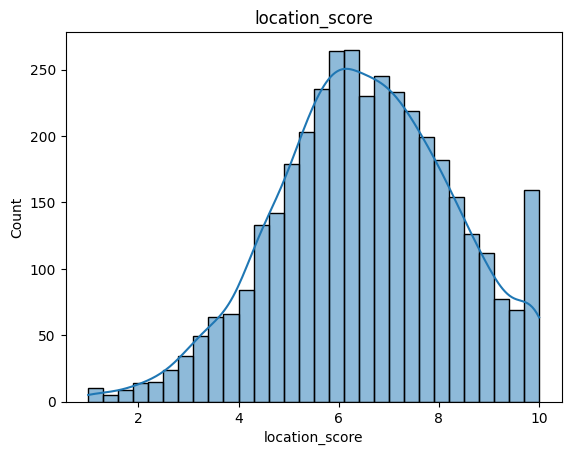

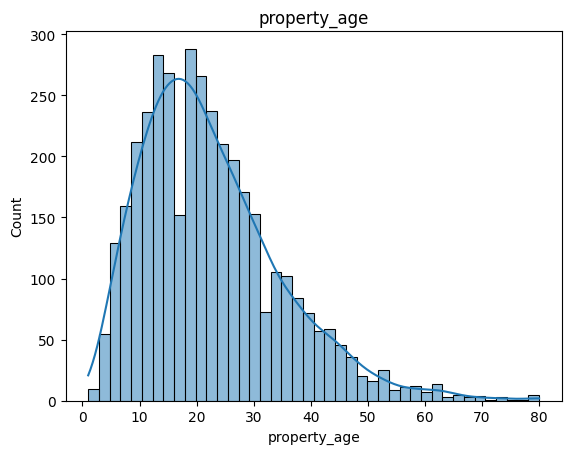

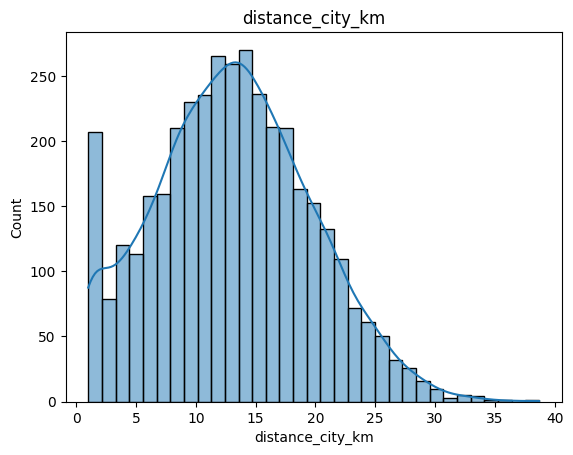

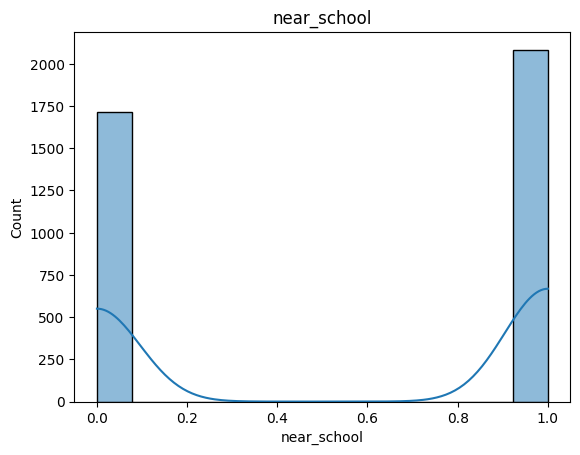

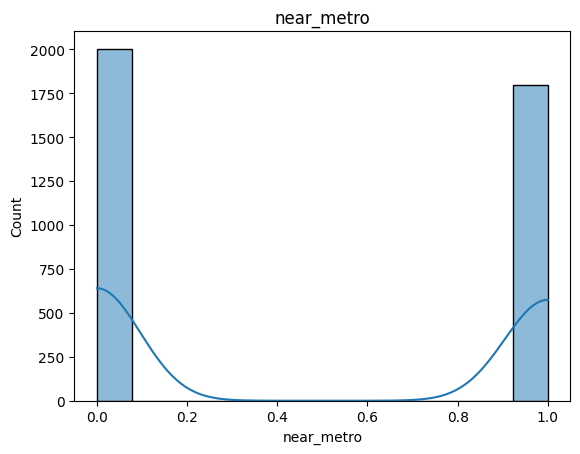

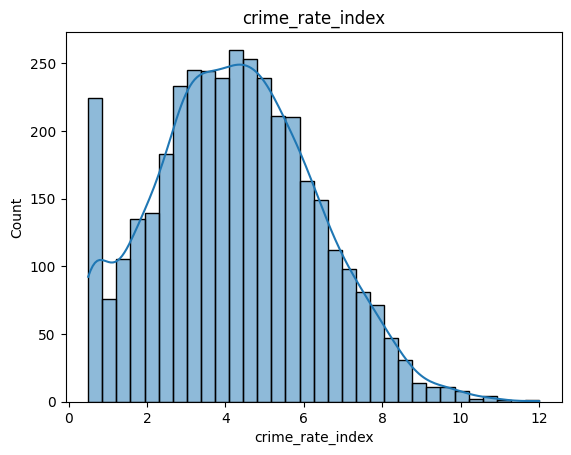

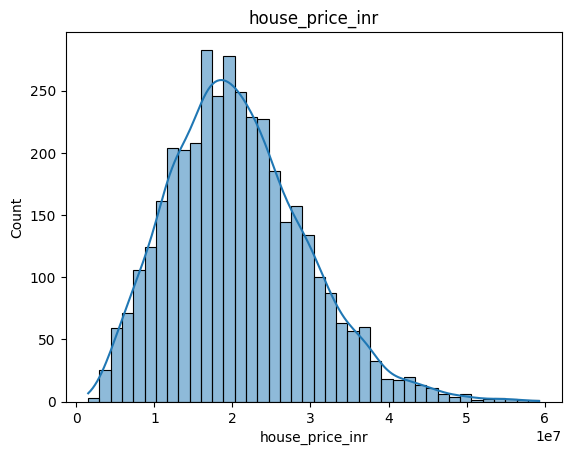

In [17]:
for col in cols:
    sns.histplot(df[col], kde=True)
    plt.title(col)
    plt.show()

In [18]:
df["property_age"].skew()

1.0479533789853845

In [19]:
df.columns

Index(['property_id', 'sale_date', 'area_sqft', 'bedrooms', 'bathrooms',
       'location_score', 'property_age', 'distance_city_km', 'near_school',
       'near_metro', 'crime_rate_index', 'house_price_inr'],
      dtype='object')

In [20]:
df["sale_date"] = pd.to_datetime(df["sale_date"])

In [21]:
df["sale_date"] 

0      2014-01-01
1      2019-12-01
2      2016-10-01
3      2013-03-01
4      2013-07-01
          ...    
3795   2010-04-01
3796   2019-04-01
3797   2020-10-01
3798   2012-03-01
3799   2013-01-01
Name: sale_date, Length: 3800, dtype: datetime64[ns]

In [22]:
df

,property_id,sale_date,area_sqft,bedrooms,bathrooms,location_score,property_age,distance_city_km,near_school,near_metro,crime_rate_index,house_price_inr
0,200001,2014-01-01,2181,6,4,8.1,21,3.8,0,0,4.84,35154898
1,200002,2019-12-01,2383,5,4,5.3,28,10.9,1,1,2.89,26710893
2,200003,2016-10-01,1047,3,3,5.9,7,27.5,0,1,4.04,11216242
3,200004,2013-03-01,1753,4,3,7.0,27,12.1,0,0,3.28,21984310
4,200005,2013-07-01,1728,4,4,10.0,32,1.4,0,1,3.84,25080429
...,...,...,...,...,...,...,...,...,...,...,...,...
3795,203796,2010-04-01,992,3,3,7.4,22,11.6,0,0,3.45,10901127
3796,203797,2019-04-01,2295,4,4,2.8,22,23.0,0,0,5.38,20662246
3797,203798,2020-10-01,2050,2,1,8.7,38,11.0,0,0,2.90,32486165
3798,203799,2012-03-01,1957,6,4,7.8,22,1.2,0,0,4.31,25004531


In [23]:
df["sale_year"] = df["sale_date"].dt.year
df["sale_month"] = df["sale_date"].dt.month
df["sale_day"] = df["sale_date"].dt.day

In [24]:
df

,property_id,sale_date,area_sqft,bedrooms,bathrooms,location_score,property_age,distance_city_km,near_school,near_metro,crime_rate_index,house_price_inr,sale_year,sale_month,sale_day
0,200001,2014-01-01,2181,6,4,8.1,21,3.8,0,0,4.84,35154898,2014,1,1
1,200002,2019-12-01,2383,5,4,5.3,28,10.9,1,1,2.89,26710893,2019,12,1
2,200003,2016-10-01,1047,3,3,5.9,7,27.5,0,1,4.04,11216242,2016,10,1
3,200004,2013-03-01,1753,4,3,7.0,27,12.1,0,0,3.28,21984310,2013,3,1
4,200005,2013-07-01,1728,4,4,10.0,32,1.4,0,1,3.84,25080429,2013,7,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3795,203796,2010-04-01,992,3,3,7.4,22,11.6,0,0,3.45,10901127,2010,4,1
3796,203797,2019-04-01,2295,4,4,2.8,22,23.0,0,0,5.38,20662246,2019,4,1
3797,203798,2020-10-01,2050,2,1,8.7,38,11.0,0,0,2.90,32486165,2020,10,1
3798,203799,2012-03-01,1957,6,4,7.8,22,1.2,0,0,4.31,25004531,2012,3,1


In [25]:
df.drop("sale_date",axis=1,inplace=True)

In [26]:
df

,property_id,area_sqft,bedrooms,bathrooms,location_score,property_age,distance_city_km,near_school,near_metro,crime_rate_index,house_price_inr,sale_year,sale_month,sale_day
0,200001,2181,6,4,8.1,21,3.8,0,0,4.84,35154898,2014,1,1
1,200002,2383,5,4,5.3,28,10.9,1,1,2.89,26710893,2019,12,1
2,200003,1047,3,3,5.9,7,27.5,0,1,4.04,11216242,2016,10,1
3,200004,1753,4,3,7.0,27,12.1,0,0,3.28,21984310,2013,3,1
4,200005,1728,4,4,10.0,32,1.4,0,1,3.84,25080429,2013,7,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3795,203796,992,3,3,7.4,22,11.6,0,0,3.45,10901127,2010,4,1
3796,203797,2295,4,4,2.8,22,23.0,0,0,5.38,20662246,2019,4,1
3797,203798,2050,2,1,8.7,38,11.0,0,0,2.90,32486165,2020,10,1
3798,203799,1957,6,4,7.8,22,1.2,0,0,4.31,25004531,2012,3,1


In [27]:
df.duplicated().sum()

0

## Exploratory Data Analysis (EDA)

Visualizations:
- Correlation heatmap
- Boxplots for outlier detection
- Distribution plots
- Feature relationships

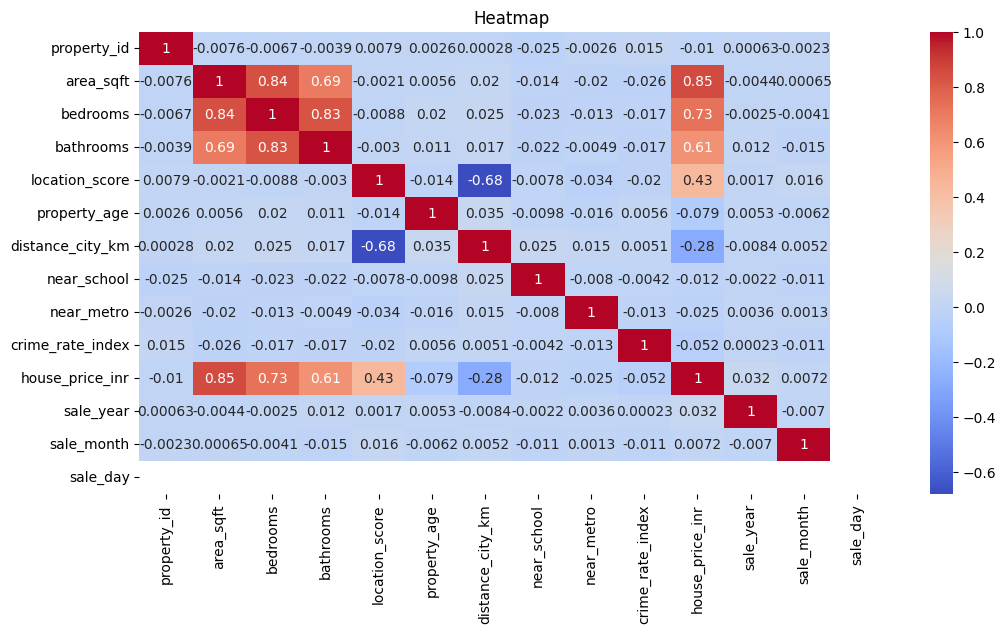

In [28]:
plt.figure(figsize=(12,6))
sns.heatmap(df.corr(numeric_only=True),annot=True,cmap="coolwarm")
plt.title("Heatmap")
plt.show()

In [29]:
X = df.drop(["property_id","house_price_inr"],axis=1)
y = df["house_price_inr"]

In [30]:
X

,area_sqft,bedrooms,bathrooms,location_score,property_age,distance_city_km,near_school,near_metro,crime_rate_index,sale_year,sale_month,sale_day
0,2181,6,4,8.1,21,3.8,0,0,4.84,2014,1,1
1,2383,5,4,5.3,28,10.9,1,1,2.89,2019,12,1
2,1047,3,3,5.9,7,27.5,0,1,4.04,2016,10,1
3,1753,4,3,7.0,27,12.1,0,0,3.28,2013,3,1
4,1728,4,4,10.0,32,1.4,0,1,3.84,2013,7,1
...,...,...,...,...,...,...,...,...,...,...,...,...
3795,992,3,3,7.4,22,11.6,0,0,3.45,2010,4,1
3796,2295,4,4,2.8,22,23.0,0,0,5.38,2019,4,1
3797,2050,2,1,8.7,38,11.0,0,0,2.90,2020,10,1
3798,1957,6,4,7.8,22,1.2,0,0,4.31,2012,3,1


In [31]:
y

0       35154898
1       26710893
2       11216242
3       21984310
4       25080429
          ...   
3795    10901127
3796    20662246
3797    32486165
3798    25004531
3799    24138565
Name: house_price_inr, Length: 3800, dtype: int64

In [32]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.2, random_state=42)

In [33]:
X_train.shape

(3040, 12)

In [34]:
X_test.shape

(760, 12)

In [35]:
y_train.shape

(3040,)

In [36]:
y_test.shape

(760,)

In [37]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
x_train_scal = scaler.fit_transform(X_train)
x_test_scal = scaler.transform(X_test)

In [38]:
x_test_scal

array([[-0.64893666, -1.05843013, -0.80897309, ..., -1.10493187,
         0.7335169 ,  0.        ],
       [ 1.03865662,  1.88879002,  2.70553664, ...,  1.38026559,
        -0.13448286,  0.        ],
       [ 0.45159324,  0.41517994,  0.06965435, ...,  1.38026559,
        -1.00248261,  0.        ],
       ...,
       [ 1.0506375 , -0.32162509,  0.06965435, ...,  0.63470635,
         0.44418365,  0.        ],
       [-0.23131723,  0.41517994,  0.06965435, ..., -0.35937263,
        -1.58114912,  0.        ],
       [ 1.38781385,  1.15198498,  0.94828178, ..., -1.10493187,
         1.02285015,  0.        ]])

## Part C: Regularized Linear Models

### Linear Regression
### Ridge Regression (L2)
### Lasso Regression (L1)

Evaluation using MSE, MAE, RMSE and R².

In [39]:
from sklearn.linear_model import LinearRegression
liner_model = LinearRegression()
liner_model.fit(X_train,y_train)
liner_pred = liner_model.predict(X_test)

In [40]:
liner_pred

array([10796422.22601324, 25651412.32137865, 23085975.32063857,
       21709667.85971463, 30857683.91760436,  3526102.54673824,
       28159475.2017388 , 29832334.48229966, 36956247.53352782,
        5080402.63750231, 32160369.92552474, 19056927.29185501,
       21811492.89337417, 12789283.36143461, 32087475.12404659,
       17132712.00142467, 23024841.6738075 , 12194144.39474091,
       30160001.96794465, 14612078.43590111, 24675046.84398809,
        2468078.91227406, 33242483.10646442, 13525018.82385036,
       15848789.02116731, 35727178.72029981, 10898452.34789887,
       27071960.53365451, 11686770.51280633, 22267267.13215962,
       15262574.81753039, 21656761.89765951, 24663978.12994227,
       24693158.77287105, 15893926.32926533, 19190713.17496279,
       17843601.5626201 , 16492917.25498024, 27744939.52139679,
       34205795.33368263, 18445955.2229456 , 18082868.24110863,
       18000033.73022091, 23256228.12238809, 21161618.49665001,
       13303628.02953437, 14577629.22465

In [41]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
mse = mean_squared_error(y_test,liner_pred)
mae = mean_absolute_error(y_test,liner_pred)
R2 = r2_score(y_test,liner_pred)
rmse = np.sqrt(mse)
n = X_test.shape[0]
p = X_test.shape[1]
adj_r2 = 1- ((1 - R2) * (n - 1) / (n - p - 1))
print("MSE:",mse)
print("MAE:",mae)
print("R2:",R2)
print("RMSE",rmse)
print("Adjusted R2:",adj_r2)

MSE: 6450121507215.395
MAE: 1945519.8388482719
R2: 0.9199092575090752
RMSE 2539708.9414370684
Adjusted R2: 0.9186226592361286


In [42]:
from sklearn.linear_model import Lasso, Ridge, LinearRegression, ElasticNet
ridge_model = Ridge(alpha=1.0)
ridge_model.fit(x_train_scal, y_train)
ridge_pred = ridge_model.predict(x_test_scal)

In [43]:
mse = mean_squared_error(y_test,ridge_pred)
mae = mean_absolute_error(y_test,ridge_pred)
R2 = r2_score(y_test,ridge_pred)
rmse = np.sqrt(mse)
n = X_test.shape[0]
p = X_test.shape[1]
adj_r2 = 1- ((1 - R2) * (n - 1) / (n - p - 1))
print("MSE:",mse)
print("MAE:",mae)
print("R2:",R2)
print("RMSE",rmse)
print("Adjusted R2:",adj_r2)

MSE: 6451358176619.914
MAE: 1945385.3977088502
R2: 0.9198939018648887
RMSE 2539952.396526343
Adjusted R2: 0.9186070569149272


In [44]:
lasso_model = Lasso(alpha=0.1)
lasso_model.fit(x_train_scal, y_train)
lasso_pred = lasso_model.predict(x_test_scal)

In [45]:
mse = mean_squared_error(y_test,lasso_pred)
mae = mean_absolute_error(y_test,lasso_pred)
R2 = r2_score(y_test,lasso_pred)
rmse = np.sqrt(mse)
n = X_test.shape[0]
p = X_test.shape[1]
adj_r2 = 1- ((1 - R2) * (n - 1) / (n - p - 1))
print("MSE:",mse)
print("MAE:",mae)
print("R2:",R2)
print("RMSE",rmse)
print("Adjusted R2:",adj_r2)

MSE: 6450121605693.379
MAE: 1945519.8445197057
R2: 0.9199092562862804
RMSE 2539708.96082472
Adjusted R2: 0.9186226579936905


In [46]:
ridge_model = Ridge(alpha=0.1)
ridge_model.fit(x_train_scal, y_train)
ridge_pred = lasso_model.predict(x_test_scal)

In [47]:
mse = mean_squared_error(y_test,ridge_pred)
mae = mean_absolute_error(y_test,ridge_pred)
R2 = r2_score(y_test,ridge_pred)
rmse = np.sqrt(mse)
n = X_test.shape[0]
p = X_test.shape[1]
adj_r2 = 1- ((1 - R2) * (n - 1) / (n - p - 1))
print("MSE:",mse)
print("MAE:",mae)
print("R2:",R2)
print("RMSE",rmse)
print("Adjusted R2:",adj_r2)

MSE: 6450121605693.379
MAE: 1945519.8445197057
R2: 0.9199092562862804
RMSE 2539708.96082472
Adjusted R2: 0.9186226579936905


In [48]:
lasso_model = Lasso(alpha=0.1)
lasso_model.fit(x_train_scal,y_train)
lasso_pred = lasso_model.predict(x_test_scal)

In [49]:
msel = mean_squared_error(y_test,lasso_pred)
mael = mean_absolute_error(y_test,lasso_pred)
R2l = r2_score(y_test,lasso_pred)
rmsel = np.sqrt(mse)
n = X_test.shape[0]
p = X_test.shape[1]
adj_r2l = 1-((1 - R2) * (n - 1) / (n - p - 1))
print("MSE:",msel)
print("MAE:",mael)
print("R2:",R2l)
print("RMSE",rmsel)
print("Adjusted R2:",adj_r2l)

MSE: 6450121605693.379
MAE: 1945519.8445197057
R2: 0.9199092562862804
RMSE 2539708.96082472
Adjusted R2: 0.9186226579936905


In [50]:
lasso_coef = pd.Series(
    lasso_model.coef_,
    index=X.columns
)

removed_features = lasso_coef

print(removed_features)

area_sqft           6.956028e+06
bedrooms            2.891290e+05
bathrooms           2.731577e+05
location_score      3.680812e+06
property_age       -6.501225e+05
distance_city_km   -2.714768e+04
near_school         1.565385e+04
near_metro          5.263399e+04
crime_rate_index   -1.406257e+05
sale_year           3.011505e+05
sale_month          1.738712e+04
sale_day            0.000000e+00
dtype: float64


## Part D: Cross-Validation Strategies

- K-Fold Cross Validation
- Leave-One-Out Cross Validation (LOOCV)
- Time Series Split Validation

In [51]:
from sklearn.model_selection import KFold
from sklearn.model_selection import cross_val_score

kfold = KFold(n_splits= 5, shuffle= True, random_state=42)

scores = cross_val_score(ridge_model, x_train_scal, y_train, cv = kfold, scoring="r2" )
print(scores)
print(scores.mean())

[0.91936465 0.90753615 0.91428793 0.92044483 0.91989065]
0.9163048421195785


In [52]:
from sklearn.model_selection import LeaveOneOut

leave = LeaveOneOut()
loo_scores = cross_val_score(ridge_model, x_train_scal,y_train,cv=leave, scoring="r2")
print(loo_scores.mean())

C:\Users\lenovo\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\metrics\_regression.py:1288: UndefinedMetricWarning: R^2 score is not well-defined with less than two samples.
  warnings.warn(msg, UndefinedMetricWarning)
C:\Users\lenovo\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\metrics\_regression.py:1288: UndefinedMetricWarning: R^2 score is not well-defined with less than two samples.
  warnings.warn(msg, UndefinedMetricWarning)
C:\Users\lenovo\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\metrics\_regression.py:1288: UndefinedMetricWarning: R^2 score is not well-defined with less than two samples.
  warnings.warn(msg, UndefinedMetricWarning)
C:\Users\lenovo\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p

nan


C:\Users\lenovo\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\metrics\_regression.py:1288: UndefinedMetricWarning: R^2 score is not well-defined with less than two samples.
  warnings.warn(msg, UndefinedMetricWarning)
C:\Users\lenovo\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\metrics\_regression.py:1288: UndefinedMetricWarning: R^2 score is not well-defined with less than two samples.
  warnings.warn(msg, UndefinedMetricWarning)
C:\Users\lenovo\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\metrics\_regression.py:1288: UndefinedMetricWarning: R^2 score is not well-defined with less than two samples.
  warnings.warn(msg, UndefinedMetricWarning)
C:\Users\lenovo\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p

In [53]:
print(loo_scores.mean())

nan


In [54]:
from sklearn.model_selection import TimeSeriesSplit
tscv = TimeSeriesSplit(n_splits=5)
for train_index, test_index in tscv.split(X):
    print(train_index, test_index)

[  0   1   2   3   4   5   6   7   8   9  10  11  12  13  14  15  16  17
  18  19  20  21  22  23  24  25  26  27  28  29  30  31  32  33  34  35
  36  37  38  39  40  41  42  43  44  45  46  47  48  49  50  51  52  53
  54  55  56  57  58  59  60  61  62  63  64  65  66  67  68  69  70  71
  72  73  74  75  76  77  78  79  80  81  82  83  84  85  86  87  88  89
  90  91  92  93  94  95  96  97  98  99 100 101 102 103 104 105 106 107
 108 109 110 111 112 113 114 115 116 117 118 119 120 121 122 123 124 125
 126 127 128 129 130 131 132 133 134 135 136 137 138 139 140 141 142 143
 144 145 146 147 148 149 150 151 152 153 154 155 156 157 158 159 160 161
 162 163 164 165 166 167 168 169 170 171 172 173 174 175 176 177 178 179
 180 181 182 183 184 185 186 187 188 189 190 191 192 193 194 195 196 197
 198 199 200 201 202 203 204 205 206 207 208 209 210 211 212 213 214 215
 216 217 218 219 220 221 222 223 224 225 226 227 228 229 230 231 232 233
 234 235 236 237 238 239 240 241 242 243 244 245 24

## Part E: Tree-Based Regression Models

### Decision Tree Regressor
### Controlled Decision Tree
### Random Forest Regressor

In [55]:
from sklearn.tree import DecisionTreeRegressor

dt = DecisionTreeRegressor(random_state=42)
dt.fit(X_train,y_train)


,"criterion criterion: {""squared_error"", ""friedman_mse"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in the half mean Poisson deviance to find splits... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 0.24 Poisson deviance criterion.",'squared_error'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.For an example of how ``max_depth`` influences the model, see:ref:`sphx_glr_auto_examples_tree_plot_tree_regression.py`.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",42
,"max_l

In [56]:
dt_pred = dt.predict(X_test)

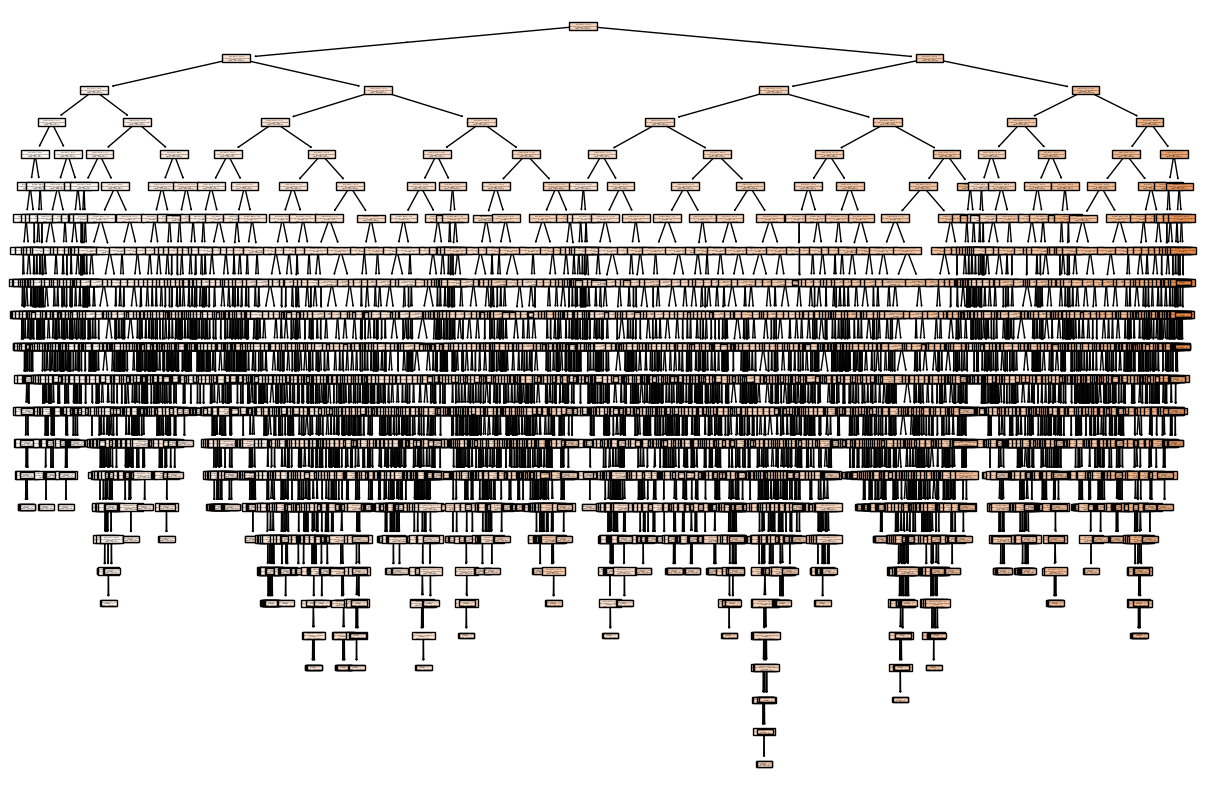

In [57]:
from sklearn.tree import plot_tree
plt.figure(figsize=(15,10))
plot_tree(dt,filled=True,feature_names=X.columns )
plt.show()

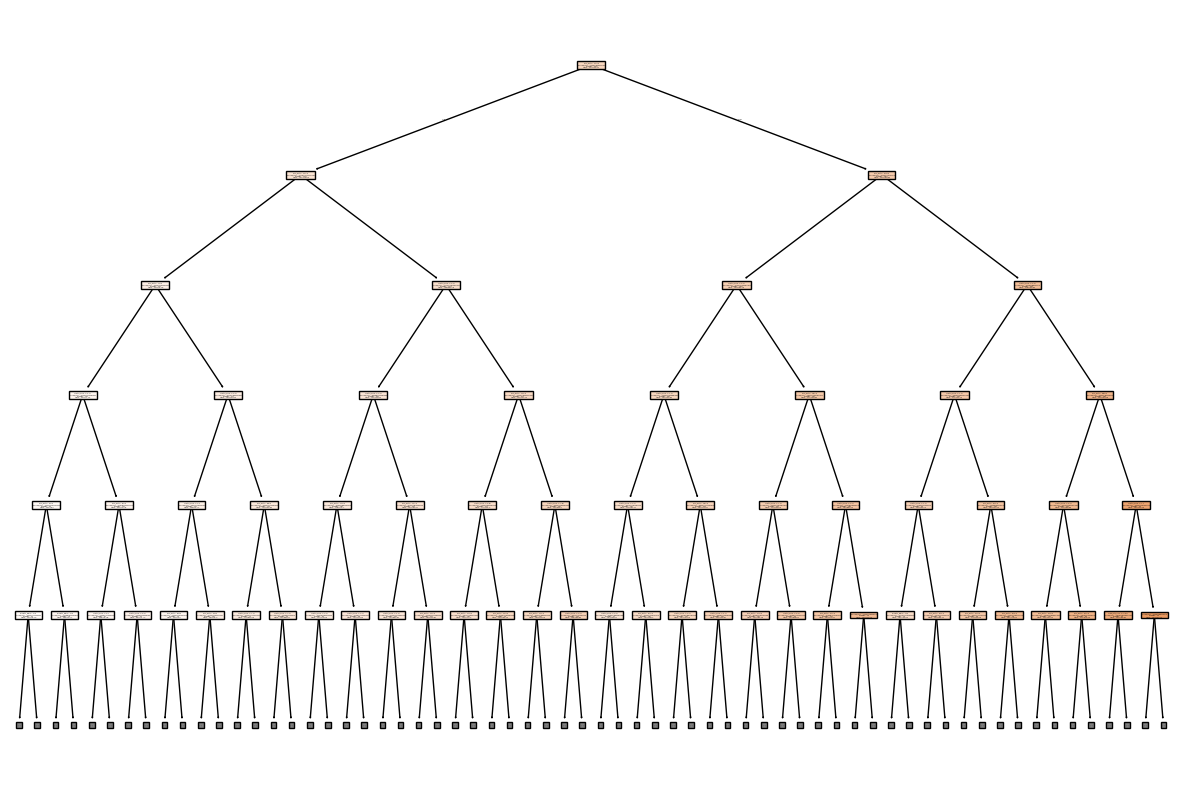

In [58]:
from sklearn.tree import plot_tree
plt.figure(figsize=(15,10))
plot_tree(dt,max_depth=5,filled=True,feature_names=X.columns )
plt.show()

In [59]:
dt_rmse = np.sqrt(
    mean_squared_error(y_test, dt_pred)
)

dt_r2 = r2_score(
    y_test,
    dt_pred
)

print("Decision Tree RMSE:", dt_rmse)
print("Decision Tree R2 Score:", dt_r2)

Decision Tree RMSE: 3277696.3420960573
Decision Tree R2 Score: 0.866601220285162


In [60]:
dt_control = DecisionTreeRegressor(
    max_depth=3,
    min_samples_split=5,
    random_state=42
)

dt_control.fit(X_train, y_train)

control_pred = dt_control.predict(X_test)

In [61]:
control_rmse = np.sqrt(
    mean_squared_error(y_test, control_pred)
)

control_r2 = r2_score(
    y_test,
    control_pred
)

print("Controlled Tree RMSE:", control_rmse)
print("Controlled Tree R2:", control_r2)

Controlled Tree RMSE: 4193886.4286544444
Controlled Tree R2: 0.7816024536154864


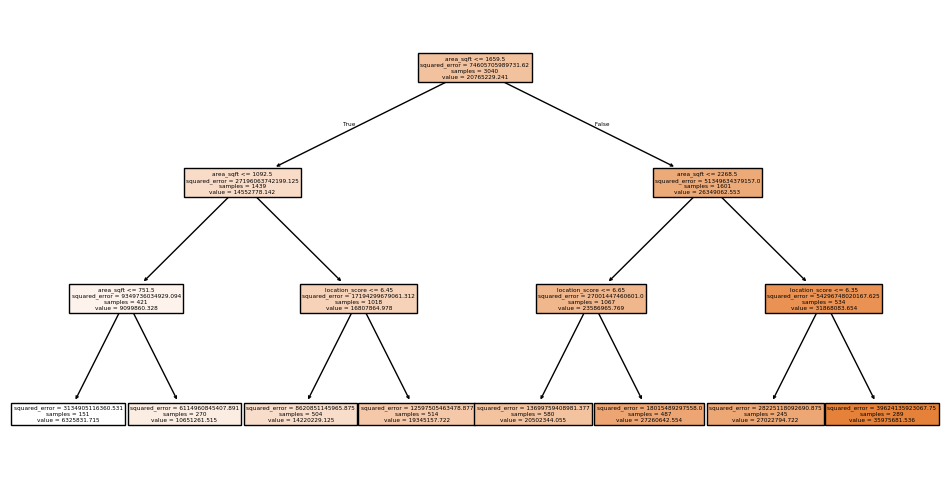

In [62]:
plt.figure(figsize=(12,6))

plot_tree(
    dt_control,
    feature_names=X.columns,
    filled=True
)

plt.show()

In [64]:
from sklearn.ensemble import RandomForestRegressor
rf_model = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

rf_model.fit(X_train, y_train)

rf_pred = rf_model.predict(X_test)

In [65]:
rf_rmse = np.sqrt(
    mean_squared_error(y_test, rf_pred)
)

rf_r2 = r2_score(
    y_test,
    rf_pred
)

print("Random Forest RMSE:", rf_rmse)
print("Random Forest R2:", rf_r2)

Random Forest RMSE: 2406259.2553653875
Random Forest R2: 0.9281049055567916


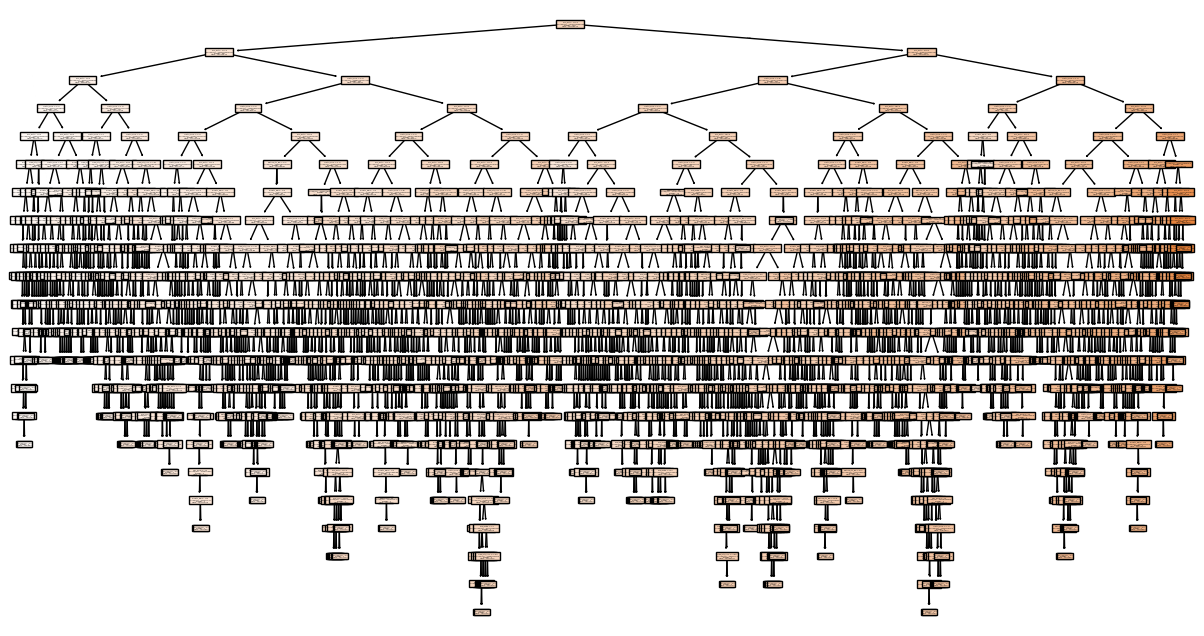

In [66]:
plt.figure(figsize=(15,8))

plot_tree(
    rf_model.estimators_[0],
    feature_names=X.columns,
    filled=True
)

plt.show()

In [67]:
comparison = pd.DataFrame({
    'Model': [
        'Decision Tree',
        'Controlled Tree',
        'Random Forest'
    ],
    'RMSE': [
        dt_rmse,
        control_rmse,
        rf_rmse
    ],
    'R2 Score': [
        dt_r2,
        control_r2,
        rf_r2
    ]
})

print(comparison)

             Model          RMSE  R2 Score
0    Decision Tree  3.277696e+06  0.866601
1  Controlled Tree  4.193886e+06  0.781602
2    Random Forest  2.406259e+06  0.928105


## Part F: Support Vector Regression (SVR)

- Linear Kernel
- Polynomial Kernel
- Tuned SVR

Performance comparison with tree-based and linear models.

In [68]:
from sklearn.svm import SVR

In [69]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [70]:
svr_linear = SVR(
    kernel='linear'
)

svr_linear.fit(
    X_train_scaled,
    y_train
)

linear_pred = svr_linear.predict(
    X_test_scaled
)

In [71]:
linear_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        linear_pred
    )
)

linear_r2 = r2_score(
    y_test,
    linear_pred
)

print("Linear SVR RMSE:", linear_rmse)
print("Linear SVR R2:", linear_r2)

Linear SVR RMSE: 8982717.415461306
Linear SVR R2: -0.0019127401175407233


In [72]:
svr_poly = SVR(
    kernel='poly',
    degree=3
)

svr_poly.fit(
    X_train_scaled,
    y_train
)

poly_pred = svr_poly.predict(
    X_test_scaled
)

poly_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        poly_pred
    )
)

poly_r2 = r2_score(
    y_test,
    poly_pred
)

print("Polynomial SVR RMSE:", poly_rmse)
print("Polynomial SVR R2:", poly_r2)

Polynomial SVR RMSE: 8987227.781309552
Polynomial SVR R2: -0.0029191454904722303


In [73]:
svr_tuned = SVR(
    kernel='rbf',
    C=100,
    gamma=0.1,
    epsilon=0.1
)

svr_tuned.fit(
    X_train_scaled,
    y_train
)

tuned_pred = svr_tuned.predict(
    X_test_scaled
)

tuned_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        tuned_pred
    )
)

tuned_r2 = r2_score(
    y_test,
    tuned_pred
)

print("Tuned SVR RMSE:", tuned_rmse)
print("Tuned SVR R2:", tuned_r2)

Tuned SVR RMSE: 8977746.948525067
Tuned SVR R2: -0.000804256767496625


In [74]:
comparison = pd.DataFrame({
    'Model': [
        'Linear Regression',
        'Decision Tree',
        'Random Forest',
        'Linear SVR',
        'Polynomial SVR',
        'Tuned SVR'
    ],
    'RMSE': [
        linear_rmse,
        dt_rmse,
        rf_rmse,
        linear_rmse,
        poly_rmse,
        tuned_rmse
    ],
    'R2 Score': [
        linear_r2,
        dt_r2,
        rf_r2,
        linear_r2,
        poly_r2,
        tuned_r2
    ]
})

print(comparison)

               Model          RMSE  R2 Score
0  Linear Regression  8.982717e+06 -0.001913
1      Decision Tree  3.277696e+06  0.866601
2      Random Forest  2.406259e+06  0.928105
3         Linear SVR  8.982717e+06 -0.001913
4     Polynomial SVR  8.987228e+06 -0.002919
5          Tuned SVR  8.977747e+06 -0.000804


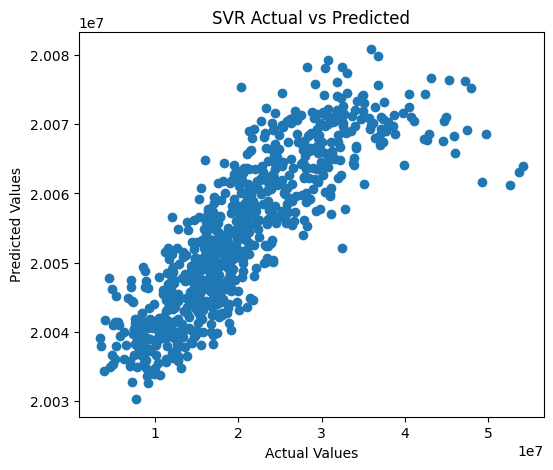

In [75]:
plt.figure(figsize=(6,5))

plt.scatter(
    y_test,
    tuned_pred
)

plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.title("SVR Actual vs Predicted")

plt.show()

## Part G: Model Comparison & Evaluation

Metrics:
- MSE
- MAE
- RMSE
- R² Score

Compare all models and identify the best-performing approach.

In [76]:
from sklearn.metrics import (
    mean_squared_error,
    mean_absolute_error,
    r2_score
)

In [77]:
def evaluate_model(
    y_true,
    y_pred
):
    
    mse = mean_squared_error(
        y_true,
        y_pred
    )

    mae = mean_absolute_error(
        y_true,
        y_pred
    )

    rmse = np.sqrt(mse)

    r2 = r2_score(
        y_true,
        y_pred
    )

    return mse, mae, rmse, r2

In [78]:
lr_mse, lr_mae, lr_rmse, lr_r2 = evaluate_model(
    y_test,
    linear_pred
)
ridge_mse, ridge_mae, ridge_rmse, ridge_r2 = evaluate_model(
    y_test,
    ridge_pred
)

lasso_mse, lasso_mae, lasso_rmse, lasso_r2 = evaluate_model(
    y_test,
    lasso_pred
)

dt_mse, dt_mae, dt_rmse, dt_r2 = evaluate_model(
    y_test,
    dt_pred
)

rf_mse, rf_mae, rf_rmse, rf_r2 = evaluate_model(
    y_test,
    rf_pred
)


svr_mse, svr_mae, svr_rmse, svr_r2 = evaluate_model(
    y_test,
    tuned_pred
)

In [79]:
results = pd.DataFrame({

    'Model': [
        'Linear Regression',
        'Ridge',
        'Lasso',
        'Decision Tree',
        'Random Forest',
        'SVR'
    ],

    'MSE': [
        lr_mse,
        ridge_mse,
        lasso_mse,
        dt_mse,
        rf_mse,
        svr_mse
    ],

    'MAE': [
        lr_mae,
        ridge_mae,
        lasso_mae,
        dt_mae,
        rf_mae,
        svr_mae
    ],

    'RMSE': [
        lr_rmse,
        ridge_rmse,
        lasso_rmse,
        dt_rmse,
        rf_rmse,
        svr_rmse
    ],

    'R2 Score': [
        lr_r2,
        ridge_r2,
        lasso_r2,
        dt_r2,
        rf_r2,
        svr_r2
    ]

})

print(results)

               Model           MSE           MAE          RMSE  R2 Score
0  Linear Regression  8.068921e+13  6.990274e+06  8.982717e+06 -0.001913
1              Ridge  6.450122e+12  1.945520e+06  2.539709e+06  0.919909
2              Lasso  6.450122e+12  1.945520e+06  2.539709e+06  0.919909
3      Decision Tree  1.074329e+13  2.385691e+06  3.277696e+06  0.866601
4      Random Forest  5.790084e+12  1.758820e+06  2.406259e+06  0.928105
5                SVR  8.059994e+13  6.986110e+06  8.977747e+06 -0.000804


In [80]:
regularized = results[
    results['Model'].isin(
        ['Ridge','Lasso']
    )
]

print(regularized)

   Model           MSE           MAE          RMSE  R2 Score
1  Ridge  6.450122e+12  1.945520e+06  2.539709e+06  0.919909
2  Lasso  6.450122e+12  1.945520e+06  2.539709e+06  0.919909


In [81]:
tree_models = results[
    results['Model'].isin(
        ['Decision Tree','Random Forest']
    )
]

print(tree_models)

           Model           MSE           MAE          RMSE  R2 Score
3  Decision Tree  1.074329e+13  2.385691e+06  3.277696e+06  0.866601
4  Random Forest  5.790084e+12  1.758820e+06  2.406259e+06  0.928105


In [82]:
svr_compare = results[
    results['Model'].isin(
        ['SVR']
    )
]

print(svr_compare)

  Model           MSE           MAE          RMSE  R2 Score
5   SVR  8.059994e+13  6.986110e+06  8.977747e+06 -0.000804


In [84]:
dt_train_pred = dt.predict(
    X_train
)

rf_train_pred = rf_model.predict(
    X_train
)

svr_train_pred = svr_tuned.predict(
    X_train_scaled
)

In [85]:
dt_train_r2 = r2_score(
    y_train,
    dt_train_pred
)

dt_test_r2 = r2_score(
    y_test,
    dt_pred
)

print(
    "Train R2:",
    dt_train_r2
)

print(
    "Test R2:",
    dt_test_r2
)

Train R2: 1.0
Test R2: 0.866601220285162


## Final Analysis & Reporting

### Conclusions
- Best model selection
- Cross-validation insights
- Feature importance observations
- Business recommendations

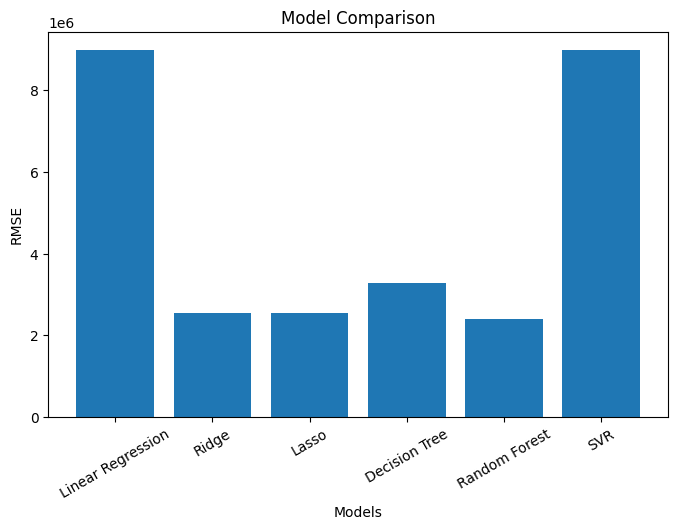

: 

In [ ]:

plt.figure(figsize=(8,5))

plt.bar(
    results['Model'],
    results['RMSE']
)

plt.xlabel("Models")
plt.ylabel("RMSE")
plt.title("Model Comparison")

plt.xticks(rotation=30)

plt.show()